# 🛍️ Customer Segmentation

**Dataset:** Mall Customers (Kaggle)

**Goal:** Cluster customers into segments based on **Annual Income** and **Spending Score**, perform scaling, explore groupings visually, apply K-Means (determine optimal k), visualize clusters in 2D, analyze average spending per cluster. Bonus: try other clustering algorithms (e.g., DBSCAN).

---


## 1️⃣ import libraries

In [18]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# For reproducibility
RANDOM_STATE = 0


---

## 2️⃣ Data Loading & Cleaning

In [19]:
df = pd.read_csv("../data/raw/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [20]:
# Quick overview
print('Shape:', df.shape)
df.info()

# Basic statistics
display(df.describe())

Shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [21]:
# Data cleaning & basic checks
# 1. Check duplicates
print('Duplicate rows:', df.duplicated().sum())

# 2. Check missing values
print('\nMissing values per column:')
print(df.isna().sum())

# 3. Ensure column names are consistent (trim spaces)
df.columns = [c.strip() for c in df.columns]

# Drop duplicates if any
if df.duplicated().sum() > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print('Dropped duplicates. New shape:', df.shape)


Duplicate rows: 0

Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


---

## 3️⃣ Exploratory Data Analysis (EDA)

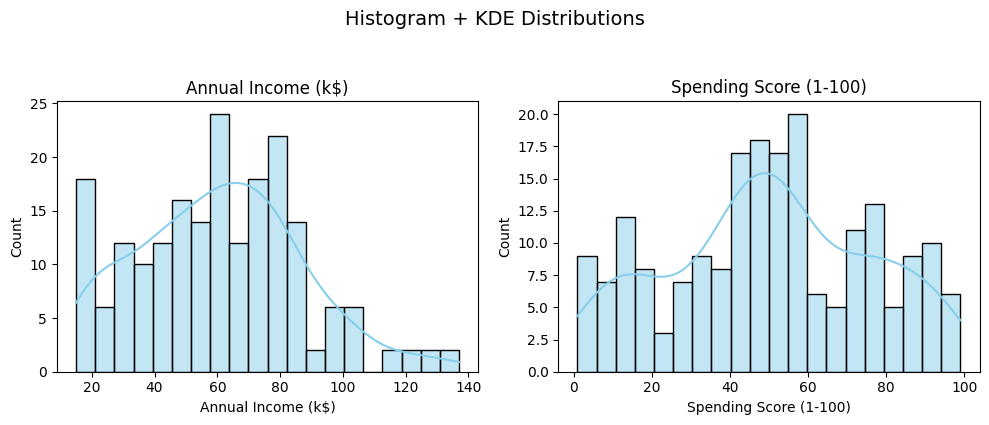

In [22]:
# EDA - Histogram + KDE (combined in one figure)
num_cols = ['Annual Income (k$)', 'Spending Score (1-100)']

fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), kde=True, bins=20, color='skyblue', edgecolor='black', ax=ax)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle("Histogram + KDE Distributions", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()


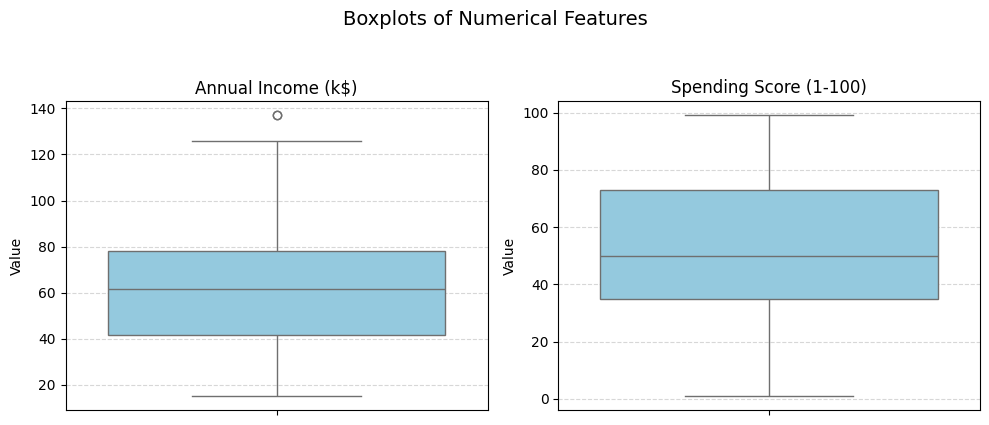

In [23]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))

for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col].dropna(), color='skyblue', ax=ax)
    ax.set_title(col)
    ax.set_ylabel('Value')
    ax.set_xlabel('')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Boxplots of Numerical Features", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

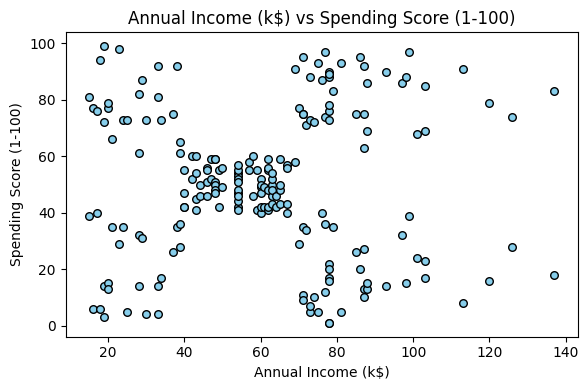

In [24]:
# Scatter plot: Annual Income vs Spending Score
x_col, y_col = 'Annual Income (k$)', 'Spending Score (1-100)'

plt.figure(figsize=(6, 4))
plt.scatter(df[x_col], df[y_col], s=30, color='skyblue', edgecolor='black')
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title(f'{x_col} vs {y_col}')
plt.tight_layout()
plt.show()

---

## 4️⃣ Model Building

### Choosing appropriate k for clustering

In [25]:
# Preprocessing: select features for clustering
scaler = StandardScaler()
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X_scaled = scaler.fit_transform(X)

In [26]:
# Elbow method (inertia) and silhouette scores
inertias = []
sil_scores = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, kmeans.labels_)
    sil_scores.append(sil)

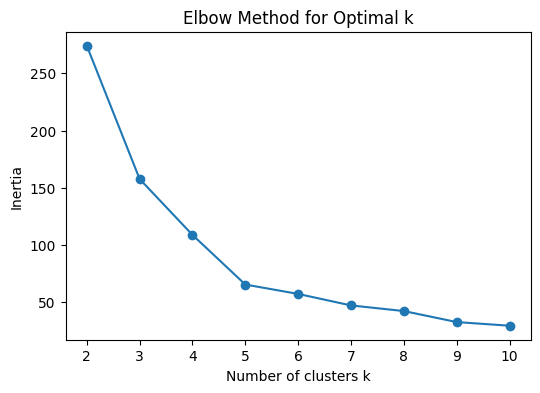

In [27]:
# Plot inertia
plt.figure(figsize=(6,4))
plt.plot(K, inertias, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(K)
plt.show()

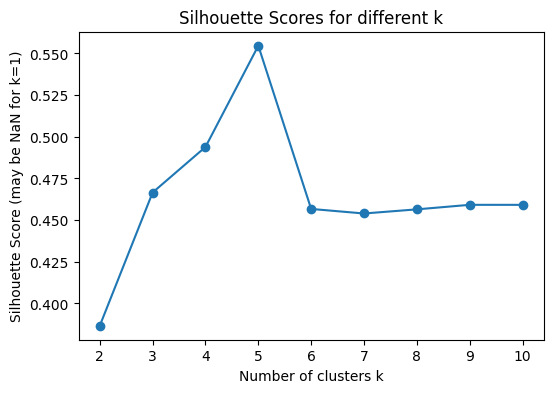

In [28]:
# Plot silhouette (only for k>=2)
plt.figure(figsize=(6,4))
plt.plot([k for k in K], sil_scores, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('Silhouette Score (may be NaN for k=1)')
plt.title('Silhouette Scores for different k')
plt.xticks(K)
plt.show()

### 📈 Number of Clusters (k)

From the **Elbow Method**, the curve starts flattening around **k = 5**, indicating diminishing returns beyond this point.

The **Silhouette Score** was also highest at **k = 5**, confirming that five clusters provide a good balance between **compactness and separation**.

✅ Therefore, **k = 5** was chosen as the optimal number of clusters for this dataset.


### Fitting and Predicting with choosen number of clusters using KMeans

In [29]:
# Fit KMeans with chosen k and attach labels
kmeans = KMeans(n_clusters=5, random_state=RANDOM_STATE)
labels = kmeans.fit_predict(X_scaled)
df['Cluster'] = labels

# Quick cluster counts
print('Cluster counts:')
print(df['Cluster'].value_counts().sort_index())

Cluster counts:
Cluster
0    81
1    39
2    35
3    23
4    22
Name: count, dtype: int64


In [30]:
df.drop(columns=['CustomerID', 'Gender'], inplace=True)

cluster_profile = df.groupby('Cluster').mean()

print('\nCluster profile (averages):')
cluster_profile


Cluster profile (averages):


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,41.114286,88.200000,17.114286
3,45.217391,26.304348,20.913043
4,25.272727,25.727273,79.363636


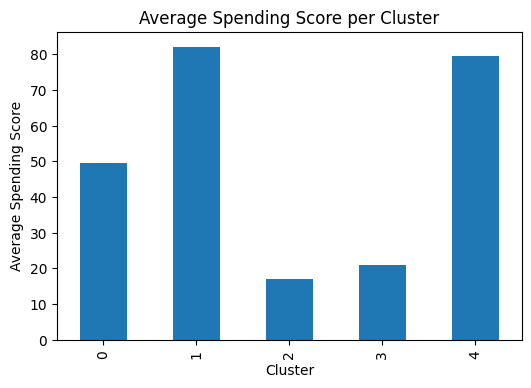

In [31]:
# Average spending (Spending Score) per cluster
avg_spending = df.groupby('Cluster')['Spending Score (1-100)'].mean().sort_index()
avg_spending.plot(kind='bar', figsize=(6,4))
plt.title('Average Spending Score per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Spending Score')
plt.show()

In [32]:
cluster_names = {
    0: "Average Spenders",
    1: "Luxury Shoppers",
    2: "Careful Rich",
    3: "Low Budget",
    4: "High Spenders"
}

df["Cluster_Name"] = df["Cluster"].map(cluster_names)

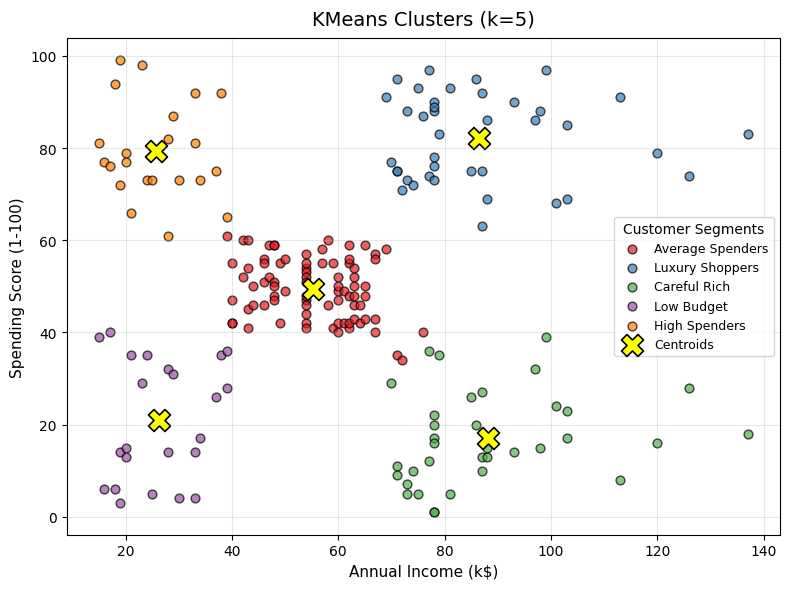

In [ ]:
# Define a pleasant color palette (same number as clusters)
palette = sns.color_palette("Set1", n_colors=kmeans.n_clusters)

plt.figure(figsize=(8,6))

# Plot points for each cluster with names in legend
for i in range(kmeans.n_clusters):
    plt.scatter(
        X.loc[df['Cluster'] == i, 'Annual Income (k$)'],
        X.loc[df['Cluster'] == i, 'Spending Score (1-100)'],
        s=40,
        c=[palette[i]],
        edgecolor='black',
        alpha=0.7,
        label=cluster_names[i] 
    )

# Plot centroids
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_orig[:,0],
    centroids_orig[:,1],
    marker='X',
    s=250,
    c='yellow',
    edgecolor='black',
    linewidth=1.2,
    label='Centroids'
)

# Labels and legend
plt.xlabel('Annual Income (k$)', fontsize=11)
plt.ylabel('Spending Score (1-100)', fontsize=11)
plt.title(f'KMeans Clusters (k={kmeans.n_clusters})', fontsize=14, pad=10)
plt.legend(title='Customer Segments', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Fitting and Predicting using DBSCAN

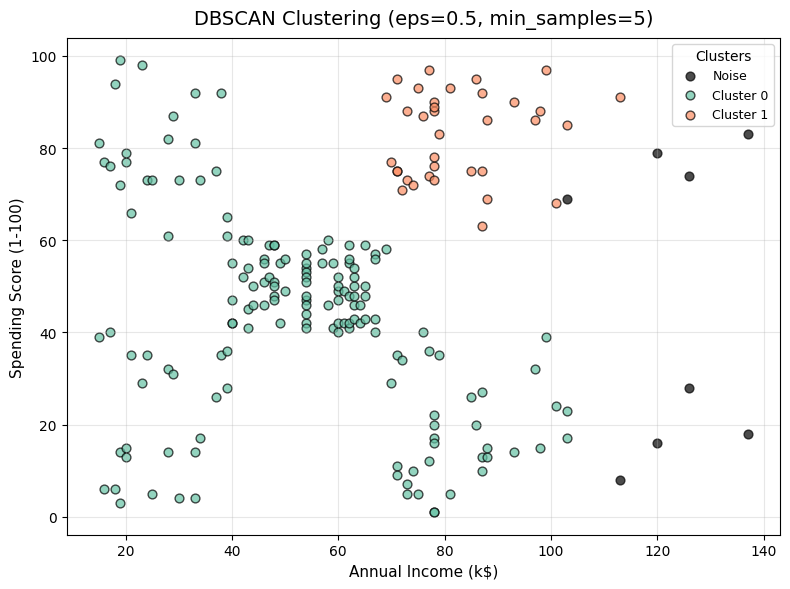

In [34]:
# Bonus: DBSCAN (try different parameters to see behavior)
from collections import Counter

db = DBSCAN(eps=0.5, min_samples=5)
db_labels = db.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = db_labels

# Styled DBSCAN visualization
unique_labels = sorted(set(db_labels))
palette = sns.color_palette("Set2", n_colors=len(unique_labels))

plt.figure(figsize=(8,6))
for label in unique_labels:
    color = 'k' if label == -1 else palette[label % len(palette)]
    plt.scatter(
        X.loc[df['DBSCAN_Cluster'] == label, 'Annual Income (k$)'],
        X.loc[df['DBSCAN_Cluster'] == label, 'Spending Score (1-100)'],
        s=40,
        c=[color],
        edgecolor='black',
        alpha=0.7,
        label='Noise' if label == -1 else f'Cluster {label}'
    )

plt.xlabel('Annual Income (k$)', fontsize=11)
plt.ylabel('Spending Score (1-100)', fontsize=11)
plt.title('DBSCAN Clustering (eps=0.5, min_samples=5)', fontsize=14, pad=10)
plt.legend(title='Clusters', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---

## 5️⃣ Saving The Labeled Dataset

In [35]:
df.to_csv("../data/processed/Mall_Customers_Segmented.csv", index=False)

---

# 🏁 Conclusion

In this analysis, we segmented mall customers based on their *Annual Income* and *Spending Score* to uncover distinct behavioral groups.  
After scaling and applying the Elbow and Silhouette methods, **five clusters (k = 5)** were selected as the most suitable structure for the data.

The K-Means clustering revealed clear customer segments:

- **Cluster 0:** Middle-income, average spenders — a balanced group.  
- **Cluster 1:** High-income, high-spending customers — premium target group.  
- **Cluster 2:** High-income, low-spending customers — potential for marketing focus to increase engagement.  
- **Cluster 3:** Low-income, low-spending customers — least profitable segment.  
- **Cluster 4:** Low-income, high-spending customers — enthusiastic spenders despite limited income.  

The **average spending score visualization** confirmed strong differences between clusters, validating the segmentation.

Additionally, **DBSCAN** was tested as an alternative density-based algorithm. While it identified two main clusters and a few outliers, K-Means provided more interpretable and balanced groupings for this dataset.

Overall, the analysis successfully demonstrates how unsupervised learning can uncover actionable customer segments that can guide targeted marketing strategies and personalized offers.